## Project 1: World Progress

In this project, you'll explore data from [Gapminder.org](http://gapminder.org), a website dedicated to providing a fact-based view of the world and how it has changed. That site includes several data visualizations and presentations, but also publishes the raw data that we will use in this project to recreate and extend some of their most famous visualizations.

The Gapminder website collects data from many sources and compiles them into tables that describe many countries around the world. All of the data they aggregate are published in the [Systema Globalis](https://github.com/open-numbers/ddf--gapminder--systema_globalis/blob/master/README.md). Their goal is "to compile all public statistics; Social, Economic and Environmental; into a comparable total dataset." All data sets in this project are copied directly from the Systema Globalis without any changes.

This project is dedicated to [Hans Rosling](https://en.wikipedia.org/wiki/Hans_Rosling) (1948-2017), who championed the use of data to understand and prioritize global development challenges.

### Logistics

**Checkpoint.** For full credit, you must complete the first 9 questions and submit your work to the Project 1 Checkpoint assignment on Canvas. After you've submitted the checkpoint, you may still change your answers before the project deadline - only your final submission will be graded for correctness.

**Rules.** Don't share your code with anybody. You are welcome to discuss questions with other students, but don't share the answers. If someone asks you for the answer, resist! Instead, you can demonstrate how you would solve a similar problem.

**Support.** You are not alone! Come to office hours, ask questions during class, and talk with your classmates. If you're ever feeling overwhelmed or don't know how to make progress, email your instructor for help. 

**Check for Excessive Runtime.** Before you submit, make sure that none of your cells take a very long time to run (e.g., several minutes or more).

**Free Response Questions:** Make sure that you put the answers to the written questions in the indicated cell which has been provided. 

**Advice.** Develop your answers incrementally. To perform a complicated table manipulation, break it up into steps, perform each step on a different line, give a new name to each intermediate result, and check that each intermediate result is what you expect. You can add any additional names or functions you want to the provided cells. Make sure that you are using distinct and meaningful variable names throughout the notebook. 

You **never** have to use just one line in this project or any others. Use intermediate variables and multiple lines as much as you would like!  

To get started, load `datascience`, `numpy`, and `plots`:

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## 1. Global Population Growth


The global population of humans reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The potential impact of exponential population growth has concerned scientists, economists, and politicians alike.

The UN Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching 11 billion by 2100. However, the UN does not rule out scenarios of more extreme growth.

<a href="http://www.pewresearch.org/fact-tank/2015/06/08/scientists-more-worried-than-public-about-worlds-growing-population/ft_15-06-04_popcount/"> 
 <img src="pew_population_projection.png"/> 
</a>

In this section, we will examine some of the factors that influence population growth and how they are changing around the world.

The first table we will consider is the total population of each country over time. Run the cell below.

In [2]:
population = Table.read_table('population.csv').where("time", are.below(2021))
population.show(3)

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


**Note:** The data for this project was downloaded in April 2020.

### Haiti

In the `population` table, the `geo` column contains three-letter codes established by the [International Organization for Standardization](https://en.wikipedia.org/wiki/International_Organization_for_Standardization) (ISO) in the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) standard. We will begin by taking a close look at Haiti. Use the Alpha-3 link to find the 3-letter code for Haiti.

**Question 1.1.** Use the `population` table to create a new table called `h_pop` that has two columns labeled `time` and `population_total`. The first column should contain the years from 1970 through 2020 (including both 1970 and 2020) and the second should contain the population of Haiti in each of those years.

<!--
BEGIN QUESTION
name: q1_1
-->

In [3]:
h_pop = population.where('geo', 'hti').where('time', are.between(1970, 2021))
h_pop = h_pop.drop('geo')
h_pop.set_format('population_total', NumberFormatter)  # don't change this line
print("h_pop")
h_pop.show(3)

h_pop


time,population_total
1970,"4,676,237"
1971,"4,757,175"
1972,"4,837,334"


Run the following cell to create a smaller table called `h_decade` that only shows the rows of h_pop where the 'time' (year) is a multiple of 10 (1970, 1980, ..., 2020). At a glance, it appears that the population of Haiti has been growing quickly indeed!

In [4]:
# Just run this cell, don't change it
tens = np.arange(1970, 2021, 10)  # 1970, 1980, ..., 2020
h_decade = h_pop.sort('time').where('time', are.contained_in(tens))
h_decade.show()

time,population_total
1970,"4,676,237"
1980,"5,643,175"
1990,"7,037,915"
2000,"8,463,802"
2010,"9,949,318"
2020,"11,402,533"


**Question 1.2.** Assign `initial` to an array that contains the population for every ten year interval from 1970 to 2010. Then, assign `changed` to an array that contains the population for every ten year interval from 1980 to 2020. You should use the `h_decade` table to create both arrays, first filtering the table to only contain the relevant years.

The **annual growth rate for a time period** is equal to 

`(changed / initial)**(1 / t) - 1` 

where `initial` is the initial amount and `changed` is the amount `t` years later.

We have provided the code below that uses  `initial` and `changed` in order to add a column to `h_decade` called `annual_growth`. 

If you are interested in how we came up with the formula for growth rates, consult the [growth rates](https://inferentialthinking.com/chapters/03/2/1/Growth.html) section of the textbook.

<!--
BEGIN QUESTION
name: q1_2
-->

In [5]:
initial = h_decade.where('time', are.below(2011)).column('population_total')  # Haiti population, 1970 - 2010
changed = h_decade.where('time', are.above(1970)).column('population_total')  # Haiti population, 1980 - 2020

growth_rates = ((changed/initial)**0.1)-1

h_1970_through_2010 = h_decade.where('time', are.below_or_equal_to(2010)) 
h_decade_growth = h_1970_through_2010.with_column('annual_growth', growth_rates)
# Don't change this line!
h_decade_growth.set_format('annual_growth', PercentFormatter)

time,population_total,annual_growth
1970,"4,676,237",1.90%
1980,"5,643,175",2.23%
1990,"7,037,915",1.86%
2000,"8,463,802",1.63%
2010,"9,949,318",1.37%


While the population has grown every decade since 1970, the annual growth rate decreased dramatically from 1980 to 2020. Let's look at some other information in order to develop a possible explanation. Run the next cell to load three additional tables of measurements about countries over time.

In [6]:
life_expectancy = Table.read_table('life_expectancy.csv').where('time', are.below(2021))
child_mortality = Table.read_table('child_mortality.csv').relabel(2, 'child_mortality_under_5_per_1000_born').where('time', are.below(2021))
fertility = Table.read_table('fertility.csv').where('time', are.below(2021))

The `life_expectancy` table contains a statistic that is often used to measure how long people live, called *life expectancy at birth*. This number, for a country in a given year, [does not measure how long babies born in that year are expected to live](http://blogs.worldbank.org/opendata/what-does-life-expectancy-birth-really-mean). Instead, it measures how long someone would live, on average, if the *mortality conditions* in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people at each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.

Run the following cells below to see `life_expectancy`, `child_mortality`, and `fertility`. Refer back to these tables as they will be helpful for answering further questions!

In [7]:
life_expectancy

geo,time,life_expectancy_years
afg,1800,28.21
afg,1801,28.2
afg,1802,28.19
afg,1803,28.18
afg,1804,28.17
afg,1805,28.16
afg,1806,28.15
afg,1807,28.14
afg,1808,28.13
afg,1809,28.12


In [8]:
child_mortality

geo,time,child_mortality_under_5_per_1000_born
afg,1800,468.58
afg,1801,468.58
afg,1802,468.58
afg,1803,468.58
afg,1804,468.58
afg,1805,468.58
afg,1806,469.98
afg,1807,469.98
afg,1808,469.98
afg,1809,469.98


In [9]:
fertility

geo,time,children_per_woman_total_fertility
abw,1800,5.64
abw,1801,5.64
abw,1802,5.64
abw,1803,5.64
abw,1804,5.64
abw,1805,5.64
abw,1806,5.64
abw,1807,5.64
abw,1808,5.64
abw,1809,5.64


**Question 1.3.** Perhaps population is growing more slowly because people aren't living as long. Use the `life_expectancy` table to draw a line graph with the years 1970 and later on the horizontal axis that shows how the *life expectancy at birth* has changed in Haiti.

<!--
BEGIN QUESTION
name: q1_3
manual: true
-->
<!-- EXPORT TO PDF -->

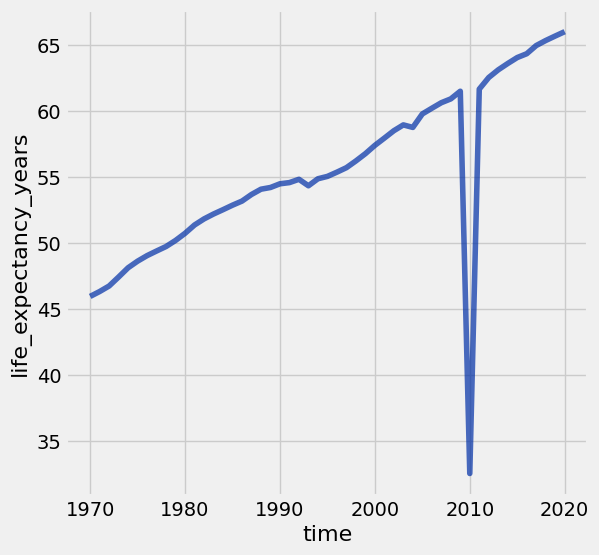

In [10]:
#Fill in code here
life_expectancy.where('geo', 'hti').where('time', are.above(1969)).plot('time', 'life_expectancy_years')

**Question 1.4.** Assuming everything else stays the same, do the trends in life expectancy in the graph above directly explain why the population growth rate decreased from 1980 to 2020 in Haiti? Why or why not? 

Hint: What happened in Haiti in 2010, and does that event explain the overall change in population growth rate?

<!--
BEGIN QUESTION
name: q1_4
manual: true
-->
<!-- EXPORT TO PDF -->

#### ANSWER
The graph shows that, in general, life expectancy increased steadily over the years 1970 to 2020, with a major outlier in 2010 due to the devastating Haiti earthquake. Neither increasing life expectancy, nor the devastation of the 2010 earthquake, directly explains the decreasing rate of growth in Haiti's population.

The `fertility` table contains a statistic that is often used to measure how many babies are being born, the *total fertility rate*. This number describes the [number of children a woman would have in her lifetime](https://www.measureevaluation.org/prh/rh_indicators/specific/fertility/total-fertility-rate), on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49. 

**Question 1.5.** Define a function `fertility_over_time` that takes the Alpha-3 code of a `country` (string) and a `start` year (integer). It returns a two-column table with labels `Year` and `Children per woman` that can be used to generate a line chart of the country's fertility rate each year, starting at the `start` year. (The resulting plot should include the `start` year and all later years that appear in the `fertility` table for that country.)

Then, in the next cell, call your `fertility_over_time` function on the Alpha-3 code for Haiti and the year 1970 in order to plot how Haiti's fertility rate has changed since 1970. Note that the function `fertility_over_time` should not return the plot itself. **The expression that draws the line plot is provided for you; please don't change it.**

<!--
BEGIN QUESTION
name: q1_5
-->

In [11]:
# Use this cell to practice making the required 2-column table for 
# Haiti, starting from the year 2000
country = 'hti'
start = 2000
two_col_fertility_haiti = fertility.where('geo', country).where('time', are.above(1999)).select(1, 2)
two_col_fertility_haiti = two_col_fertility_haiti.relabeled(0, 'Year').relabeled(1, 'Children per woman')
two_col_fertility_haiti.show()

Year,Children per woman
2000,4.3
2001,4.18
2002,4.07
2003,3.96
2004,3.85
2005,3.76
2006,3.67
2007,3.58
2008,3.49
2009,3.41


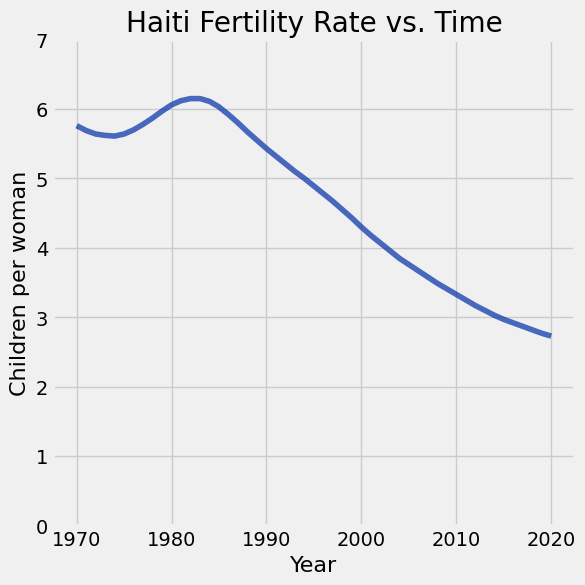

In [12]:
# Add code to complete the function definition
def fertility_over_time(country, start):
    """Returns a two-column table that shows a country's total 
    fertility rate for each year (starting from `start`)."""
    two_col_fertility = fertility.where('geo', country).where('time', are.above(start - 1)).select(1, 2)
    two_col_fertility = two_col_fertility.relabeled(0, 'Year').relabeled(1, 'Children per woman')
    return two_col_fertility

# You should *not* change the next four lines
haiti_code = 'hti'
fertility_over_time(haiti_code, 1970).plot(0, 1) 
plots.title('Haiti Fertility Rate vs. Time')
plots.ylim(0,7); 

**Question 1.6.** Assuming everything else is constant, do the trends in fertility in the graph above help directly explain why the population growth rate decreased from 1980 to 2020 in Haiti? Why or why not?

<!--
BEGIN QUESTION
name: q1_6
manual: true
-->
<!-- EXPORT TO PDF -->

### Answer
If women are having fewer babies then, yes, that could be part of the explanation for a decrease in the population growth rate.

It has been observed that lower fertility rates are often associated with lower child mortality rates. The link has been attributed to family planning: if parents can expect that their children will all survive into adulthood, then they will choose to have fewer children. We can see if this association is evident in Haiti by plotting the relationship between total fertility rate and [child mortality rate per 1000 children](https://en.wikipedia.org/wiki/Child_mortality).

**Question 1.7.** Using both the `fertility` and `child_mortality` tables, draw a scatter plot that has Haiti's total fertility on the horizontal axis and its child mortality on the vertical axis with one point for each year, starting with 1970.

**The expression that draws the scatter plot is provided for you; please don't change it.** Instead, create a 3-column table called `post_1969_fertility_and_child_mortality` with the appropriate column labels and data in order to generate the chart correctly. Use the label `Children per woman` to describe total fertility and the label `Child deaths per 1000 born` to describe child mortality. Include a `time` column (for the years).

<!--
BEGIN QUESTION
name: q1_7
manual: false
-->

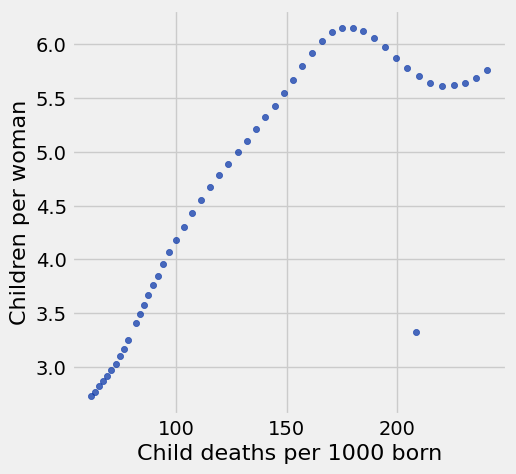

In [13]:
hti_fertility = (fertility.where('geo', 'hti')
    .where('time', are.above(1969))
    .drop(0).relabeled(1, 'Children per woman')
    )
hti_child_mortality = (child_mortality.where('geo', 'hti')
    .where('time', are.above(1969))
    .drop(0).relabeled(1, 'Child deaths per 1000 born')
    )
post_1969_fertility_and_child_mortality = hti_fertility.join('time', hti_child_mortality, 'time')

# Don't change this line!
post_1969_fertility_and_child_mortality.scatter('Child deaths per 1000 born', 'Children per woman')

**Question 1.8.** Discuss the scatter plot:

(a) In one or two sentences, describe the association (if any) that is illustrated by this scatter diagram. 

(b) Does the diagram show that reduced child mortality **causes** parents to choose to have fewer children? 

(c) Beyond the general association, are there any irregularities or odd points that would be worth investigating? 

<!--
BEGIN QUESTION
name: q1_8
manual: true
-->
<!-- EXPORT TO PDF -->

### Answer
(a) The overall pattern is a positive association: higher child mortality tends to be associated with higher fertility rates. 

(b) These are observational data, not data from a controlled randomized experiment. So NO, the plot does not show causation.

(c) The association is less clear when child deaths exceed 175 per 1000 born, and there is an extreme outlier (high child mortality paired with low fertility rate), presumably due to the 2010 earthquake.

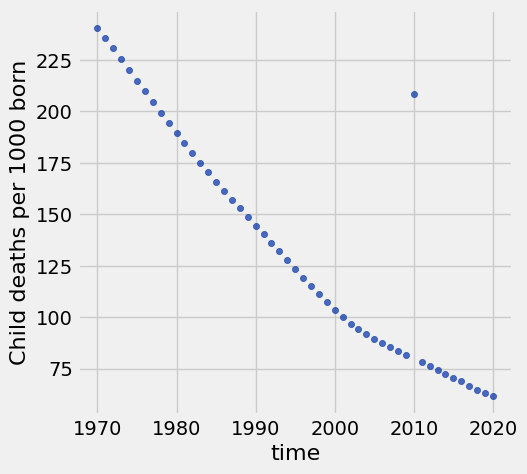

In [14]:
# Don't change this line!
post_1969_fertility_and_child_mortality.scatter('time', 'Child deaths per 1000 born')

**Question 1.9.** Using our knowledge that historical factors may affect Haiti's population, we decide to plot the child mortality rate per 1000 born against time, as seen in the scatter plot above. Does this new visualization give us a better understanding of the outlier in the Question 8 scatterplot? What is the most likely explanation for the outlier in the Question 8 scatterplot?
<!--
BEGIN QUESTION
name: q1_9
manual: true
-->
<!-- EXPORT TO PDF -->

### Answer
Yes, this plot makes it clear that the outlier in the previous plot is for data from 2010. So the most likely explanation is that the 2010 earthquake caused many child deaths and also brought down the fertility rate.

### Checkpoint (due Friday 2/20)

  - To earn full credit on Project 1, you need to have made a solid effort on all the questions up to this point.
  - You should feel at least somewhat confident that your work up to this point is correct.
  - You can still edit and revise this much of the project; the checkpoint is meant to encourage everyone to get off to a good start on the project.
  
#### Congratulations, you have reached the checkpoint! 

  - Run all the cells, in order, up to this point.
  - Save and checkpoint.
  - Downoad as HTML.
  - Separately, download as .ipynb
  - Upload both files to Canvas (Checkpoint assignment for Project 1).

### The World

The change observed in Haiti since 1970 can also be observed in many other developing countries: health services improve, life expectancy increases, and child mortality decreases. At the same time, the fertility rate often plummets, and so the population growth rate decreases despite increasing longevity.

Run the cell below to generate two overlaid histograms, one for 1960 and one for 2013, that show the distributions of total fertility rates for these two years among all 201 countries in the `fertility` table.

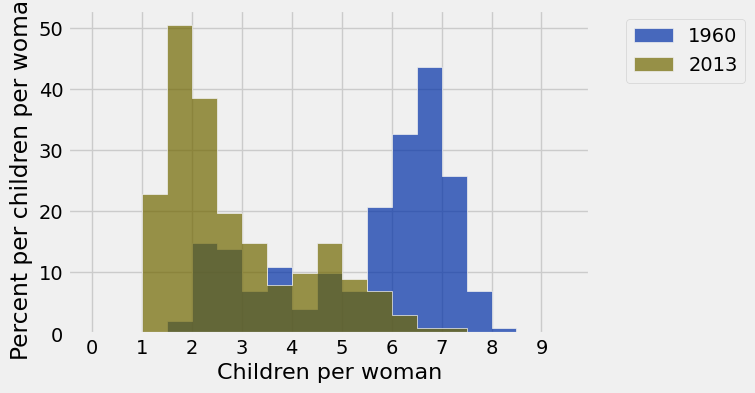

In [15]:
Table().with_columns(
    '1960', fertility.where('time', 1960).column(2),
    '2013', fertility.where('time', 2013).column(2)
).hist(bins=np.arange(0, 10, 0.5), unit='child per woman')
_ = plots.xlabel('Children per woman')
_ = plots.ylabel('Percent per children per woman')
_ = plots.xticks(np.arange(10))

**Question 1.10.** Assign `fertility_statements` to an array of the numbers of each statement below that can be correctly inferred from these histograms.

1. In 1960, less than 20% of countries had a fertility rate below 3.
1. At least half of countries had a fertility rate between 5 and 8 in 1960.
1. In 2013, about 40% of countries had a fertility rate between 1.5 and 2.
1. At least half of countries had a fertility rate below 3 in 2013.
1. More countries had a fertility rate above 3 in 1960 than in 2013.

<!--
BEGIN QUESTION
name: q1_9
-->

In [22]:
# Check that #2 is TRUE
fertility_1960 = fertility.where('time', 1960)
count = fertility_1960.where("children_per_woman_total_fertility", are.between(5, 8)).num_rows
count / 201

0.6865671641791045

In [24]:
# Check that #3 is FALSE
fertility_2013 = fertility.where('time', 2013)
count = fertility_2013.where("children_per_woman_total_fertility", are.between(1.5, 2)).num_rows
count / 201

0.2537313432835821

In [31]:
# Check that #4 is ... ?
print("Median children per woman in 2013:", np.median(fertility.where('time', 2013).column(2)))
print("More than half of countries in 2013 had less than 3 children per woman fertility rage")

Median children per woman in 2013: 2.32
More than half of countries in 2013 had less than 3 children per woman fertility rage


In [32]:
fertility_statements = make_array(1, 2, 4, 5)  # make an array here
fertility_statements

array([1, 2, 4, 5])

**Question 1.11.** The world population in a given year is the *sum* of all the countries' populations in that year. 

  - Make a 2-column table showing the world population for each year in the `population` table.
  - Use your new table to draw a line plot of the world population from 1800 through 2020. 
  - Use appropriate column labels in the new table so that the axis labels of your plot are clear and helpful. You will probably need to use `relabeled` to improve at least one of the column labels before drawing the line plot.

<!--
BEGIN QUESTION
name: q1_10
manual: true
-->
<!-- EXPORT TO PDF -->

In [33]:
population.show(2)

geo,time,population_total
afg,1800,3280000
afg,1801,3280000


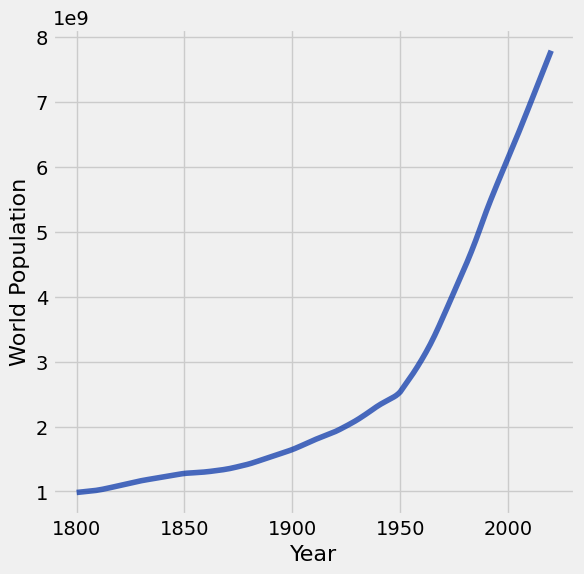

In [38]:
#Fill in code here
# 2-column table showing the world population for each year `population` table
pop_by_year = population.select(1, 2).group('time', np.sum).relabel(0, 'Year').relabel(1, 'World Population')
pop_by_year.plot(0, 1)

**Question 1.12.** Define a function `stats_for_year` that takes a `year` parameter and returns a table of statistics. The table it returns should have four columns: 

  - `geo`
  - `population_total`
  - `children_per_woman_total_fertility`
  - `child_mortality_under_5_per_1000_born`
  
Each row should contain one Alpha-3 country code and three statistics: population, fertility rate, and child mortality for that `year`; gather these statistics from the `population`, `fertility` and `child_mortality` tables you have already created. 

**Only include rows for which all three statistics are available for the country and year.**

In addition, restrict the result to country codes that appear in `big_50`, an array of the 50 most populous countries in 2020. This restriction will speed up computations later in the project.

After you have written your definition for `stats_for_year`, try calling `stats_for_year` on any year between 1960 and 2020. Try to understand the output of stats_for_year.

*Hint*: Do your best to write the function correctly and check that it works correctly before moving on.

<!--
BEGIN QUESTION
name: q1_11
manual: false
-->

In [39]:
# We first create a population table that only includes the 
# 50 countries with the largest 2010 populations. We focus on 
# these 50 countries only so that plotting later will run faster.
big_50 = (
    population.where('time', are.equal_to(2020))
    .sort("population_total", descending=True)
    .take(np.arange(50))
    .column('geo')
)
print(big_50)

population_of_big_50 = (
    population.where('time', are.above(1959))
    .where('geo', are.contained_in(big_50))
)
population_of_big_50.show(3)

['chn' 'ind' 'usa' 'idn' 'pak' 'bra' 'nga' 'bgd' 'rus' 'mex' 'jpn' 'eth'
 'phl' 'egy' 'vnm' 'cod' 'tur' 'irn' 'deu' 'tha' 'gbr' 'fra' 'ita' 'tza'
 'zaf' 'mmr' 'ken' 'kor' 'col' 'esp' 'uga' 'arg' 'dza' 'sdn' 'ukr' 'irq'
 'afg' 'pol' 'can' 'mar' 'sau' 'uzb' 'per' 'ago' 'mys' 'moz' 'gha' 'yem'
 'npl' 'ven']


geo,time,population_total
afg,1960,8996967
afg,1961,9169406
afg,1962,9351442


In [43]:
# Barb's test that joining the tables is a solid plan

joined_1 = population_of_big_50.join(
    ['geo', 'time'],     # List of column names in table1
    fertility            # The other table to join with
)
joined_2 = joined_1.join(
    ['geo', 'time'],
    child_mortality
)
joined_2

geo,time,population_total,children_per_woman_total_fertility,child_mortality_under_5_per_1000_born
afg,1960,8996967,7.45,356.9
afg,1961,9169406,7.45,350.89
afg,1962,9351442,7.45,345.34
afg,1963,9543200,7.45,340.15
afg,1964,9744772,7.45,334.92
afg,1965,9956318,7.45,329.58
afg,1966,10174840,7.45,324.34
afg,1967,10399936,7.45,318.95
afg,1968,10637064,7.45,313.58
afg,1969,10893772,7.45,308.06


In [54]:
def stats_for_year(year):
    """Return a table of the stats for each country that year."""
    p = population_of_big_50.where('time', are.equal_to(year)).drop('time')
    f = fertility.where('time', are.equal_to(year)).drop('time')
    c = child_mortality.where('time', are.equal_to(year)).drop('time')
    joined_1 = population_of_big_50.join(
        ['geo', 'time'],     
        fertility            
    )
    joined_2 = joined_1.join(
        ['geo', 'time'],
        child_mortality
    )
    return joined_2.where('time', year).drop('time')

stats_for_year(2020)

geo,population_total,children_per_woman_total_fertility,child_mortality_under_5_per_1000_born
afg,38928341,4.04,58.08
ago,32866268,5.41,72.29
arg,45195777,2.23,9.4
bgd,164689383,2,27.7
bra,212559409,1.67,13.47
can,37742157,1.56,4.89
chn,1439323774,1.65,8.09
cod,89561404,5.72,84.53
col,50882884,1.78,13.48
deu,83783945,1.49,3.24


**Question 1.13.** Create a table called `pop_by_decade` with two columns called `decade` and `population`. It has a row for each `year` since 1960 that starts a decade. The `population` column contains the total population of all countries included in the result of `stats_for_year(year)` for the first `year` of the decade. For example, 1960 is the first year of the 1960's decade. You should see that these countries contain most of the world's population.

*Hint:* One approach is to define a function `pop_for_year` that computes this total population, then `apply` it to the `decade` column.  The `stats_for_year` function from the previous question may be useful here.

This first test is just a sanity check for your helper function if you choose to use it. You will not lose points for not implementing the function `pop_for_year`.

**Note:** The cell where you will generate the `pop_by_decade` table is below the cell where you can choose to define the helper function `pop_for_year`. You should define your `pop_by_decade` table in the cell that starts with the table `decades` being defined. 

<!--
BEGIN QUESTION
name: q1_12_0
manual: false
points: 0
-->

In [50]:
def pop_for_year(year):
    return np.sum(stats_for_year(year).column('population_total'))

pop_for_year(2020)

6765161289

Now that you've defined your helper function (if you've chosen to do so), define the `pop_by_decade` table.

<!--
BEGIN QUESTION
name: q1_12
manual: false
-->

In [58]:
decades = Table().with_column('decade', np.arange(1960, 2021, 10))
pop_array = decades.apply(pop_for_year, 'decade')
pop_by_decade = decades.with_column('population', pop_array)
pop_by_decade.set_format(1, NumberFormatter)

decade,population
1960,"2,635,123,897"
1970,"3,221,457,416"
1980,"3,890,044,418"
1990,"4,656,339,803"
2000,"5,377,062,169"
2010,"6,064,674,132"
2020,"6,765,161,289"


The `countries` table describes various characteristics of countries. The `country` column contains the same codes as the `geo` column in each of the other data tables (`population`, `fertility`, and `child_mortality`). The `world_6region` column classifies each country into a region of the world. Run the cell below to inspect the data.

In [60]:
countries = Table.read_table('countries.csv').where('country', are.contained_in(population.group('geo').column('geo')))
countries.select('country', 'name', 'world_6region')

country,name,world_6region
afg,Afghanistan,south_asia
ago,Angola,sub_saharan_africa
alb,Albania,europe_central_asia
and,Andorra,europe_central_asia
are,United Arab Emirates,middle_east_north_africa
arg,Argentina,america
arm,Armenia,europe_central_asia
atg,Antigua and Barbuda,america
aus,Australia,east_asia_pacific
aut,Austria,europe_central_asia


**Question 1.14.** Create a table called `region_counts` that has two columns, `region` and `count`. It should contain two columns: a region column and a count column that contains the number of countries in each region that appear in the result of `stats_for_year(2020)`. For example, one row would have `south_asia` as its `world_6region` value and an integer as its `count` value: the number of large South Asian countries for which we have population, fertility, and child mortality numbers from 2020.

<!--
BEGIN QUESTION
name: q1_13
-->

In [78]:
# First I make a two-column table showing the 50 counties along with their regions
stats2020 = stats_for_year(2020).select(0).relabel(0, 'country')
regions = countries.select('country', 'world_6region')
regions = regions.join('country', stats2020).relabel(1, 'region').select(1, 0)
regions

region,country
south_asia,afg
sub_saharan_africa,ago
america,arg
south_asia,bgd
america,bra
america,can
east_asia_pacific,chn
sub_saharan_africa,cod
america,col
europe_central_asia,deu


In [79]:
# To get the counts, use `.group`
region_counts = regions.group('region')
region_counts

region,count
america,8
east_asia_pacific,9
europe_central_asia,10
middle_east_north_africa,7
south_asia,5
sub_saharan_africa,11


The following scatter diagram compares total fertility rate and child mortality rate for each country in 2020. The area of each dot represents the population of the country, and the color represents its region of the world. Run the cell. Do you think you can identify any of the dots?

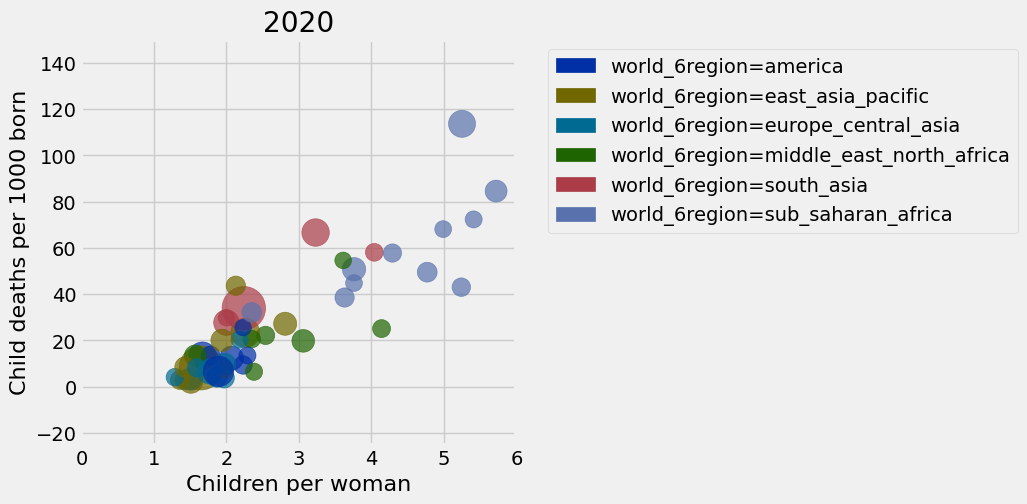

In [80]:
from functools import lru_cache as cache

# This cache annotation makes sure that if the same year
# is passed as an argument twice, the work of computing
# the result is only carried out once.
@cache(None)
def stats_relabeled(year):
    """Relabeled and cached version of stats_for_year."""
    return stats_for_year(year).relabel(2, 'Children per woman').relabel(3, 'Child deaths per 1000 born')

def fertility_vs_child_mortality(year):
    """Draw a color scatter diagram comparing child mortality and fertility."""
    with_region = stats_relabeled(year).join('geo', countries.select('country', 'world_6region'), 'country')
    with_region.scatter(2, 3, sizes=1, group=4, s=500)
    plots.xlim(0,6)
    plots.ylim(-25, 150)
    plots.title(year)

fertility_vs_child_mortality(2020)

**Question 1.15.** Assign `scatter_statements` to an array of the numbers of each statement below that can be inferred from this scatter diagram for 2020. 
1. Most countries had a fertility rate above 5.
1. There was a positive association between child mortality and fertility for these countries in 2020.
1. There was a negative association between child mortality and fertility for these countries in 2020.
1. The two largest countries by population also had the two highest child mortality rates.

<!--
BEGIN QUESTION
name: q1_14
-->

In [81]:
scatter_statements = make_array(2)

Now is a great time to take a break and watch a presentation on these data by [Hans Rosling in a 2010 TEDx talk](https://www.gapminder.org/videos/reducing-child-mortality-a-moral-and-environmental-imperative).

## 2. Global Poverty


In 1800, 85% of the world's 1 billion people lived in *extreme poverty*, defined by the United Nations as "a condition characterized by severe deprivation of basic human needs, including food, safe drinking water, sanitation facilities, health, shelter, education and information." A common measure of extreme poverty is a person living on less than \$1.25 per day.

In 2018, the proportion of people living in extreme poverty was estimated to be 8%. Although the world rate of extreme poverty has declined consistently for hundreds of years, the number of people living in extreme poverty is still over 600 million. The United Nations recently adopted an [ambitious goal](http://www.un.org/sustainabledevelopment/poverty/): "By 2030, eradicate extreme poverty for all people everywhere."
In this section, we will examine extreme poverty trends around the world.

First, load the population and poverty rate by country and year and the country descriptions. While the `population` table has values for every recent year for many countries, the `poverty` table only includes certain years for each country in which a measurement of the rate of extreme poverty was available.

In [95]:
population = Table.read_table('population.csv')
countries = (
    Table.read_table('countries.csv')
    .where('country', are.contained_in(population.group('geo').column('geo')))
)
poverty = Table.read_table('poverty.csv')
print('poverty -- this table has info on', poverty.group('geo').num_rows, 'different countries')
poverty.show(3)

poverty -- this table has info on 145 different countries


geo,time,extreme_poverty_percent_people_below_125_a_day
alb,1996,0.2
alb,2002,0.73
alb,2004,0.53


In [86]:
print('countries')
countries.show(3)

countries


country,g77_and_oecd_countries,income_groups,is--country,iso3166_1_alpha2,iso3166_1_alpha3,iso3166_1_numeric,iso3166_2,landlocked,latitude,longitude,main_religion_2008,name,un_state,unicef_region,unicode_region_subtag,world_4region,world_6region
afg,g77,low_income,True,AF,AFG,4,nan,landlocked,33,66,muslim,Afghanistan,True,sa,AF,asia,south_asia
ago,g77,upper_middle_income,True,AO,AGO,24,nan,coastline,-12.5,18.5,christian,Angola,True,ssa,AO,africa,sub_saharan_africa
alb,others,upper_middle_income,True,AL,ALB,8,nan,coastline,41,20,muslim,Albania,True,eca,AL,europe,europe_central_asia


**Question 2.1.** Assign `latest_poverty` to a three-column table with one row for each country that appears in the `poverty` table. The first column should contain the 3-letter code for the country. The second column should contain the most recent year for which an extreme poverty rate is available for the country. The third column should contain the poverty rate in that year. **Do not change the last line, so that the labels of your table are set correctly.**

*Hint*: think about how ```group``` works: it does a sequential search of the table (from top to bottom) and collects values in the array in the order in which they appear, and then applies a function to that array. The `first` function may be helpful, but you are not required to use it.

<!--
BEGIN QUESTION
name: q2_1
-->

In [91]:
poverty.where('geo', 'aze')

geo,time,extreme_poverty_percent_people_below_125_a_day
aze,1995,25.23
aze,2001,6.27
aze,2002,0.02
aze,2003,0.04
aze,2004,0
aze,2005,0
aze,2008,0.31


In [89]:
def first(values):
    return values.item(0)
    
# Trying to find a way to use .group
poverty.sort('time', descending=True).group('geo', first)

geo,time first,extreme_poverty_percent_people_below_125_a_day first
ago,2009,43.37
alb,2012,0.46
arg,2011,1.41
arm,2012,1.75
aus,2003,1.36
aut,2004,0.34
aze,2008,0.31
bdi,2006,81.32
bel,2000,0.5
ben,2012,51.61


In [93]:
def first(values):
    return values.item(0)

latest_poverty = poverty.sort('time', descending=True).group('geo', first)
# Do not change the following lines of code!
latest_poverty = (
    latest_poverty
    .relabeled(0, 'geo')
    .relabeled(1, 'time')
    .relabeled(2, 'poverty_percent')
)
latest_poverty  # CHECK THAT STUDENT RESULT HAS 145 ROWS

geo,time,poverty_percent
ago,2009,43.37
alb,2012,0.46
arg,2011,1.41
arm,2012,1.75
aus,2003,1.36
aut,2004,0.34
aze,2008,0.31
bdi,2006,81.32
bel,2000,0.5
ben,2012,51.61


In [96]:
population

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000
afg,1803,3280000
afg,1804,3280000
afg,1805,3280000
afg,1806,3280000
afg,1807,3280000
afg,1808,3280000
afg,1809,3280000


**Question 2.2.** Using both `latest_poverty` and `population`, create a four-column table called `recent_poverty_total` with one row for each country in `latest_poverty`. The four columns should have the following labels and contents:
1. `geo` contains the 3-letter country code,
1. `poverty_percent` contains the most recent poverty percent,
1. `population_total` contains the population of the country in 2010,
1. `poverty_total` contains the number of people in poverty **rounded to the nearest integer**, based on the 2010 population and most recent poverty rate. 

Hint: In forming values for the last column, you might want to use `np.rint()`, which is documented [HERE](https://numpy.org/doc/stable/reference/generated/numpy.rint.html).

<!--
BEGIN QUESTION
name: q2_2
-->

In [101]:
# It seems we can start with latest_poverty table and join the population_2020 table
population_2010 = population.where('time', 2010)
poverty_and_population = latest_poverty.join('geo', population_2010).select(0, 2, 4)
poverty_and_population

geo,poverty_percent,population_total
ago,43.37,23356247
alb,0.46,2948029
arg,1.41,40895751
arm,1.75,2877314
aus,1.36,22154687
aut,0.34,8409945
aze,0.31,9032465
bdi,81.32,8675606
bel,0.5,10938735
ben,51.61,9199254


In [103]:
# Need a plan for poverty_total: contains the number of people in poverty 
# rounded to the nearest integer, 
# based on the 2010 population and most recent poverty rate.
def pov_total(geo):
    '''Takes a three-letter country code, geo.
    Returns the number of people in poverty in that country
    based on the poverty_and_population table.'''
    T = poverty_and_population.where('geo', geo)
    pov_rate = T.column(1).item(0)/100
    pop_total = T.column(2).item(0)
    return round(pov_rate * pop_total)

pov_total('ago')

10129604

In [104]:
# Check the previous result: 
round(.4337 * 23356247)

10129604

In [105]:
# Apply the function to the table to get an array of values for last column
pov_total_array = poverty_and_population.apply(pov_total, 'geo')
pov_total_array[:5]

array([10129604,    13561,   576630,    50353,   301304])

In [108]:
recent_poverty_total = poverty_and_population.with_column('poverty_total', pov_total_array)
print('recent_poverty_total')
recent_poverty_total  # CHECK THAT STUDENT TABLE HAS 145 ROWS

recent_poverty_total


geo,poverty_percent,population_total,poverty_total
ago,43.37,23356247,10129604
alb,0.46,2948029,13561
arg,1.41,40895751,576630
arm,1.75,2877314,50353
aus,1.36,22154687,301304
aut,0.34,8409945,28594
aze,0.31,9032465,28001
bdi,81.32,8675606,7055003
bel,0.5,10938735,54694
ben,51.61,9199254,4747735


The `countries` table includes not only the name and region of countries, but also their positions on the globe.

In [112]:
countries.select('country', 'name', 'world_4region', 'latitude', 'longitude')

country,name,world_4region,latitude,longitude
afg,Afghanistan,asia,33,66
ago,Angola,africa,-12.5,18.5
alb,Albania,europe,41,20
and,Andorra,europe,42.5078,1.52109
are,United Arab Emirates,asia,23.75,54.5
arg,Argentina,americas,-34,-64
arm,Armenia,europe,40.25,45
atg,Antigua and Barbuda,americas,17.05,-61.8
aus,Australia,asia,-25,135
aut,Austria,europe,47.3333,13.3333


**Question 2.3.** Using both `countries` and `recent_poverty_total`, create a five-column table called `poverty_map` with one row for every country in `recent_poverty_total`.  The five columns should have the following labels and contents:
1. `latitude` contains the country's latitude,
1. `longitude` contains the country's longitude,
1. `name` contains the country's name,
1. `region` contains the country's region from the `world_4region` column of `countries`,
1. `poverty_percent` contains the country's poverty percentage.

<!--
BEGIN QUESTION
name: q2_4
-->

In [114]:
countries2 = countries.select('country', 'name', 'world_4region', 'latitude', 'longitude')
countries2.show(1)

country,name,world_4region,latitude,longitude
afg,Afghanistan,asia,33,66


In [127]:
poverty_map = (countries2.join('country', recent_poverty_total, 'geo')
    .select(3, 4, 1, 2, 5)
    .relabel(3, 'region')
)
poverty_map

latitude,longitude,name,region,poverty_percent
-12.5,18.5,Angola,africa,43.37
41,20,Albania,europe,0.46
-34,-64,Argentina,americas,1.41
40.25,45,Armenia,europe,1.75
-25,135,Australia,asia,1.36
47.3333,13.3333,Austria,europe,0.34
40.5,47.5,Azerbaijan,europe,0.31
-3.5,30,Burundi,africa,81.32
50.75,4.5,Belgium,europe,0.5
9.5,2.25,Benin,africa,51.61


Run the cell below to draw a map of the world in which the areas of circles represent the percentage of people in each country living in extreme poverty. Double-click on the map to zoom in.

In [128]:
# It may take a few seconds to generate this map.
colors = {'africa': 'blue', 'europe': 'black', 'asia': 'red', 'americas': 'green'}
scaled = poverty_map.with_columns(
    'poverty_percent', 10* poverty_map.column('poverty_percent'),
    'region', poverty_map.apply(colors.get, 'region')
)
scaled = scaled.relabeled('region', 'color').relabeled('poverty_percent', 'area')
Circle.map_table(scaled)

Although people live in extreme poverty throughout the world (with more than 5 million in the United States), the largest numbers are in Asia and Africa.

**Question 2.4.** Assign `largest` to a three-column table with the `name` (not the 3-letter code), `region` (as in `poverty_map`), and `poverty_total` of the 10 countries with the largest **number** (not percentage) of people living in extreme poverty. The rows should be in order by `poverty_total`, descending.

<!--
BEGIN QUESTION
name: q2_5
-->

In [129]:
geo_and_name_lookup = countries.select('country', 'name').relabel('country', 'geo')
geo_and_name_lookup

geo,name
afg,Afghanistan
ago,Angola
alb,Albania
and,Andorra
are,United Arab Emirates
arg,Argentina
arm,Armenia
atg,Antigua and Barbuda
aus,Australia
aut,Austria


In [140]:
T = (recent_poverty_total.join('geo', geo_and_name_lookup)
                         .join('name', poverty_map)
                         .select('name', 'region', 'poverty_total')
    )
T = T.sort('poverty_total', descending=True)
largest = T.take(np.arange(10))
largest.set_format('poverty_total', NumberFormatter)
largest

name,region,poverty_total
India,asia,"291,660,639"
Nigeria,africa,"98,319,537"
China,asia,"85,687,544"
Bangladesh,asia,"63,826,375"
"Congo, Dem. Rep.",africa,"56,635,412"
Indonesia,asia,"39,177,145"
Ethiopia,africa,"32,242,742"
Pakistan,asia,"22,858,700"
Tanzania,africa,"19,281,872"
Madagascar,africa,"18,543,643"


Although the number of people living in extreme poverty has been increasing in Nigeria and the United States, the massive decreases in China and India have shaped the overall trend that extreme poverty is decreasing worldwide, both in percentage and in absolute number. 

To learn more, watch [Hans Rosling in a 2015 film](https://www.gapminder.org/videos/dont-panic-end-poverty/) about the UN goal of eradicating extreme poverty from the world. 

**You're finished!** Congratulations on mastering data visualization and table manipulation. Time to submit.

## 3. Submission

  - Use the **Kernel** menu to **Restart Kernel & Run All Cells**.
  - Read through your report to check for any glitches.
  - Save and export notebook as HTML.
  - Download your .ipynb file.
  - Upload the two files to Canvas (Project 1 Final).
